Visualizing EnMAP data

In [21]:
import os
import glob

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
import datetime


#%matplotlib inline  
import matplotlib as mpl
import matplotlib.pyplot as plt

rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22})


import hgrs


opj = os.path.join

hgrs.__version__
opj = os.path.join


Import data (.bil and .xml for metadata)

In [10]:
l1c_path = "/data/satellite/enmap/l1c/ENMAP01-____L1C-DT0000112067_20250124T160300Z_002_V010502_20250508T165054Z"


In [11]:
driver = hgrs.Driver('enmap')

l1c_prod = driver.driver(l1c_path,reflectance_unit=True)
l1c_prod.Rtoa.load()
l1c_prod

/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/rioxarray/_io.py:671: UserWarning: Offsets differ across bands. The 'scale_factor' attribute will not be added. See the 'scales' attribute.
  warnings.warn(
/home/harmel/anaconda3/envs/py12/lib/python3.12/site-packages/rioxarray/_io.py:680: UserWarning: Offsets differ across bands. The 'add_offset' attribute will not be added. See the 'offsets' attribute.
  warnings.warn(


<xarray.Dataset> Size: 4GB
Dimensions:      (wl: 224, x: 1273, y: 1205)
Coordinates:
    fwhm         (wl) float64 2kB 6.996 6.668 6.424 6.251 ... 7.224 7.192 7.158
  * wl           (wl) float64 2kB 418.4 424.0 429.5 ... 2.438e+03 2.445e+03
  * x            (x) float64 10kB 3.594e+05 3.595e+05 ... 3.976e+05 3.976e+05
  * y            (y) float64 10kB 4.607e+06 4.607e+06 ... 4.571e+06 4.571e+06
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2025-01-24T16:02:55.997693
Data variables:
    Ltoa         (wl, y, x) float32 1GB dask.array<chunksize=(224, 512, 512), meta=np.ndarray>
    F0           (wl) float64 2kB 1.744e+03 1.684e+03 1.605e+03 ... 55.37 54.53
    sza          (y, x) float64 12MB 61.8 61.8 61.8 61.8 ... 61.44 61.44 61.44
    saa          (y, x) float64 12MB 166.2 166.2 166.2 ... 166.4 166.4 166.4
    vza          (y, x) float64 12MB 15.0 15.0 15.0 15.0 ... 14.99 14.99 14.99
    vaa          (y, x) float64 12MB 99.83 99.83 99.83 ... 100.9 100.9 100.9
    raa          (y, x) float64 12MB 66.32 66.32 66.32 ... 65.56 65.56 65.56
    Rtoa         (wl, y, x) float64 3GB nan nan nan nan nan ... nan nan nan nan
Attributes:
    description:       EnMAP L1C cube data
    L1C_product_name:  ENMAP01-____L1C-DT0000112067_20250124T160300Z_002_V010...
    acquisition_date:  2025-01-24 16:02:55.997693

In [4]:
data

<xarray.Dataset> Size: 1GB
Dimensions:      (wl: 224, x: 1273, y: 1205)
Coordinates:
    fwhm         (wl) float64 2kB 6.996 6.668 6.424 6.251 ... 7.224 7.192 7.158
  * wl           (wl) float64 2kB 418.4 424.0 429.5 ... 2.438e+03 2.445e+03
  * x            (x) float64 10kB 3.594e+05 3.595e+05 ... 3.976e+05 3.976e+05
  * y            (y) float64 10kB 4.607e+06 4.607e+06 ... 4.571e+06 4.571e+06
    spatial_ref  int64 8B 0
    time         datetime64[ns] 8B 2025-01-24T16:02:55.997693
Data variables:
    Ltoa         (wl, y, x) float32 1GB dask.array<chunksize=(1, 1205, 1273), meta=np.ndarray>
    F0           (wl) float64 2kB 1.744e+03 1.684e+03 1.605e+03 ... 55.37 54.53
    sza          (y, x) float64 12MB 61.8 61.8 61.8 61.8 ... 61.44 61.44 61.44
    saa          (y, x) float64 12MB 166.2 166.2 166.2 ... 166.4 166.4 166.4
    vza          (y, x) float64 12MB 15.0 15.0 15.0 15.0 ... 14.99 14.99 14.99
    vaa          (y, x) float64 12MB 99.83 99.83 99.83 ... 100.9 100.9 100.9
    raa          (y, x) float64 12MB 66.32 66.32 66.32 ... 65.56 65.56 65.56
Attributes:
    description:  EnMAP L1C cube data

Visualize the radiance and reflectance above the atmosphere

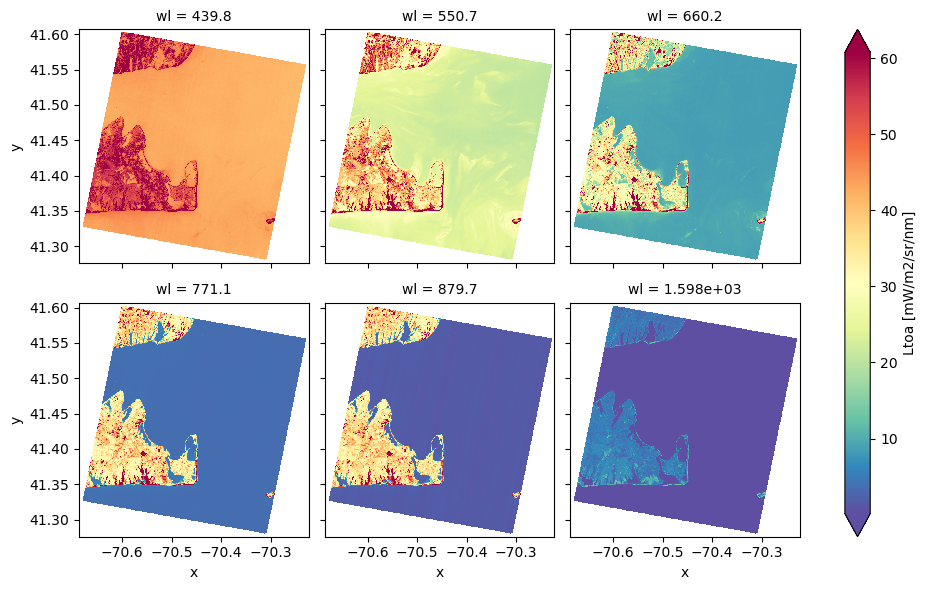

In [12]:
#Radiance / Luminance

fig = l1c_prod.Ltoa.sel(wl=[440,550,660,770,880,1600], method='nearest').rio.reproject(4326).plot.imshow(
    col='wl', col_wrap=3, cmap=plt.cm.Spectral_r, robust=True
)
#plt.savefig(root_path+'figure_rtoa.jpg', format='jpg', dpi=300)
plt.show()

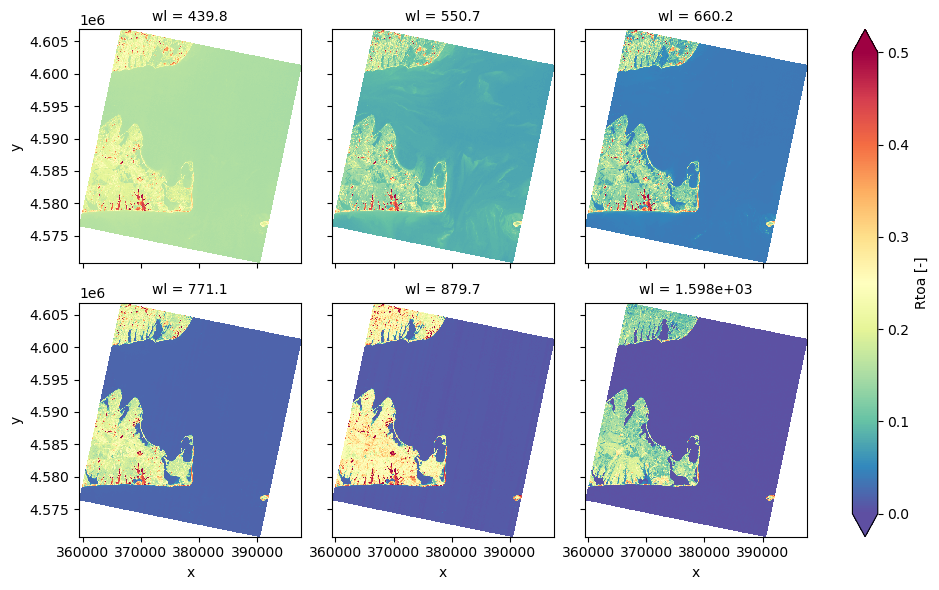

In [13]:
# Reflectance

l1c_prod.Rtoa.sel(wl=[440,550,660,770,880,1600],method='nearest').plot.imshow(col='wl',col_wrap=3,cmap=plt.cm.Spectral_r,robust=True, vmin = 0 , vmax = 0.5 )

In [18]:
import panel as pn
import geopandas as gpd
import matplotlib as mpl
#hv.extension('bokeh')
pn.extension()
from grstbx import visual

v=visual.ViewSpectral(l1c_prod.Rtoa.isel(wl=range(0,93,5)) ,reproject=True)
print(v)
v.minmax=[0,0.25]
v.minmaxvalues=(0,0.1)
v.visu()

Column
    [0] WidgetBox
        [0] Markdown(str)
        [1] Column
            [0] Row
                [0] Markdown(str)
                [1] RadioButtonGroup(options=[0, 1, 2, 3, 4, ...], value=2)
            [1] Row
                [0] Row
                    [0] Markdown(str)
                    [1] DatePicker(enabled_dates=[datetime.date(2025, ...], start=datetime.date(2025, ..., value=datetime.date(2025, ...)
                [1] Row
                    [0] Markdown(str)
                    [1] Select(options=['CartoDark', ...], value='CartoDark')
            [2] Row
                [0] Row
                    [0] Markdown(str)
                    [1] EditableRangeSlider(end=0.25, name='Range Slider', step=0.0001, value=(0, 0.1), width=300)
                [1] Row
                    [0] Markdown(str)
                    [1] FloatSlider(name='Opacity', step=0.05, value=0.95)
                [2] Row
                    [0] Markdown(str)
                    [1] Select(options=['CET_D13', 'bky', ...], value='CET_D13')
        [2] HoloViews(Layout)

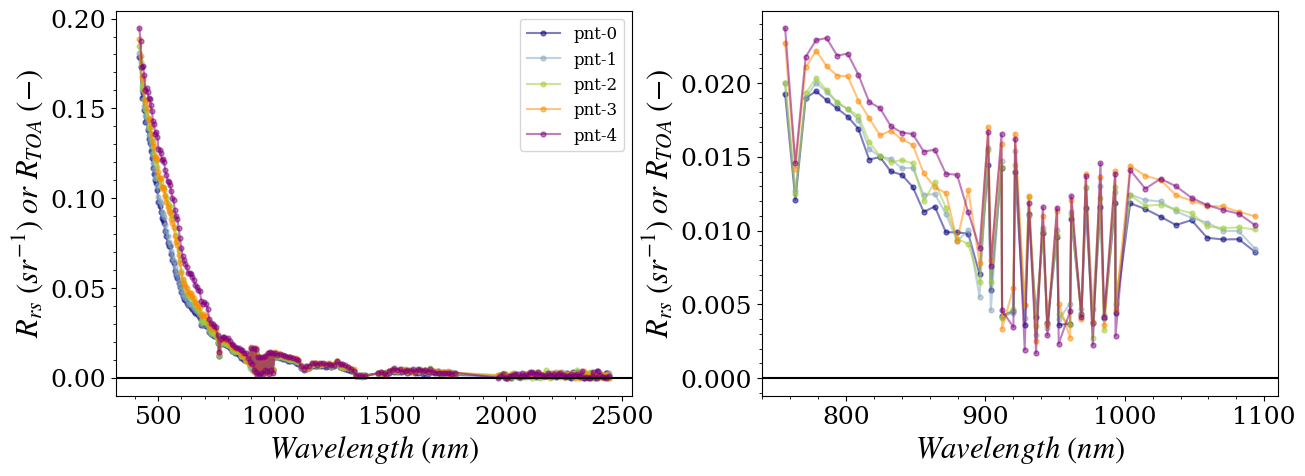

In [24]:


crs = l1c_prod.rio.crs
poi_stream = v.poi_stream
geom = poi_stream.data
geom=gpd.points_from_xy(geom['x'],geom['y'])#,crs="EPSG3857")index=[0], c
geom =gpd.GeoDataFrame(crs=3857, geometry=geom).to_crs(crs)
Ndata = len(geom)
cmap = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['navy', "blue", 'lightskyblue',
                                                     "grey",   'forestgreen','yellowgreen',
                                                     "khaki", "gold",
                                                     'orangered', "firebrick", 'purple'])
norm = mpl.colors.Normalize(vmin=0.0,vmax=Ndata-1)


wl_range=slice(750,1100)
alpha=0.5
lw=1.5
ms=3.5

fig,axs = plt.subplots(1,2,figsize=(15,5))#,sharey=True)   
fig.subplots_adjust(hspace=0.05, wspace=0.25)
ax=axs[0]
indexes=np.dstack([geom.geometry.x,geom.geometry.y])[0]
for ii,index in enumerate(indexes):
    color=cmap(norm(ii))
   
    
    toa=l1c_prod.Rtoa.sel(x=index[0],y=index[1],method='nearest')
    toa.plot(label='pnt-'+str(ii),marker='o',ms=ms,lw=lw,c=color,alpha=alpha,ax=ax)
    toa.sel(wl=wl_range).plot(label='pnt-'+str(ii),marker='o',ms=ms,lw=lw,alpha=alpha,c=color,ax=axs[1])


for ax in  axs:
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})\ or\ R_{TOA}\ (-)$')
    ax.axhline(0,color='k')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_title('')
    ax.minorticks_on() 
    
   

axs[0].legend(fontsize=12)